Fetching Housing Data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk
housing = pd.read_csv("housing.csv")

Viewing dataset

In [3]:
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


getting info about what are the feature

In [4]:

housing.info()

###you can see that there are some missing values in the total_bedrooms column. We will have to deal with those missing values before we can use this data to train a machine learning model.####

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


find out what categories exist and how many districts belong to each category by using the
value_counts() method:

In [5]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

summary of the numerical features can be find by using descirbe() method

Note that Null are ignored here

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Seeing this through histogram   

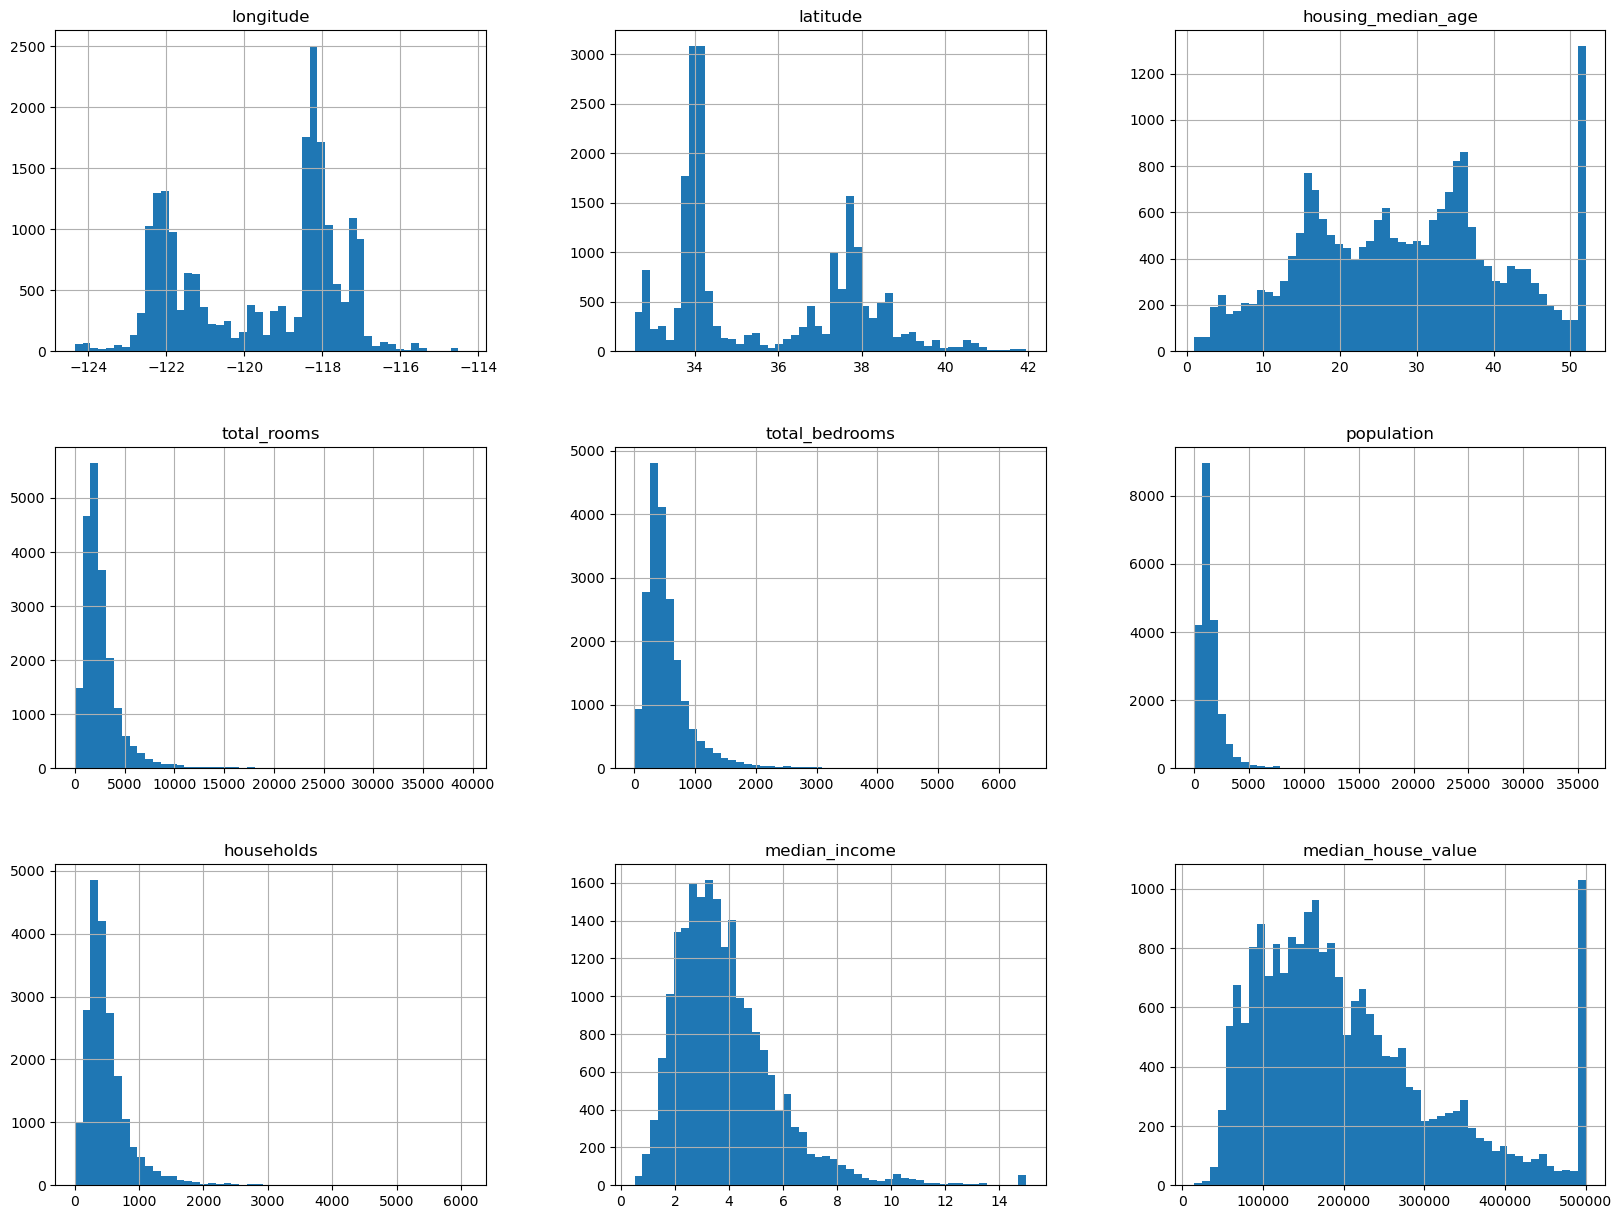

In [7]:
housing.hist(bins=50,figsize=(20,15))
plt.show()

Split Dataset for traing and testing purpose.
20% for testing and 80% for training

In [8]:
def split_train_test(data, test_ratio):
    np.random.seed(29) ## this is used to ensure that the same random numbers are generated every time you run the code. This is important for reproducibility.and 29 means always start suffeling from page index 29 ##
    shuffled_indices = np.random.permutation(len(data)) ##this line basically shuffles the data set in random permutation ##
    test_set_size = int(len(data)*test_ratio) ##lenth of testing data set is 20% of total dataset length ##
    test_indices = shuffled_indices[:test_set_size] ##from first index till test_set_size-1 index are belongs to testing dataset ##
    train_indices = shuffled_indices[test_set_size:] ## from test_set_size index till last belong to training dataset ##
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set))
print(len(test_set))

16512
4128


Housing does not have any identifier so we use latitude and longitude as identifer beacuse it will not change over a year


In [9]:
housing_with_id = housing.reset_index() ## this line is used to reset the index of the data frame and create a new column called index which will be used as an identifier for each row in the data frame. ##
housing_with_id["id"] = housing["longitude"]*1000+ housing["latitude"] ## this line is used to create a new column called id which is a combination of longitude and latitude. This is done because longitude and latitude together can be used as an identifier for each row in the data frame. ##
housing_with_id.head(100)

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY,-122222.20
96,96,-122.26,37.82,31.0,4596.0,1331.0,2048.0,1180.0,2.8345,183800.0,NEAR BAY,-122222.18
97,97,-122.26,37.81,29.0,335.0,107.0,202.0,91.0,2.0062,125000.0,NEAR BAY,-122222.19
98,98,-122.26,37.82,22.0,3682.0,1270.0,2024.0,1250.0,1.2185,170000.0,NEAR BAY,-122222.18


scikit-learn provide special fuction to split test and train data

In [10]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=29) ## this line is used to split the data into training and testing data set. test_size is the percentage of data that will be used for testing and random_state is used to ensure that the same random numbers are generated every time you run the code. This is important for reproducibility. ##

assumption here is median housing price depend on median income of area

here median income classified in 5 class(c1,c2,c3,c4,c5)
c1 = 0-1.5
c2 = 1.5-3
c3 = 3-4.5
c4 = 4.5-6
c5 = 5-left over
1.5 means 15000
3 means 30000
median income padded with 1/10000 factor

<Axes: >

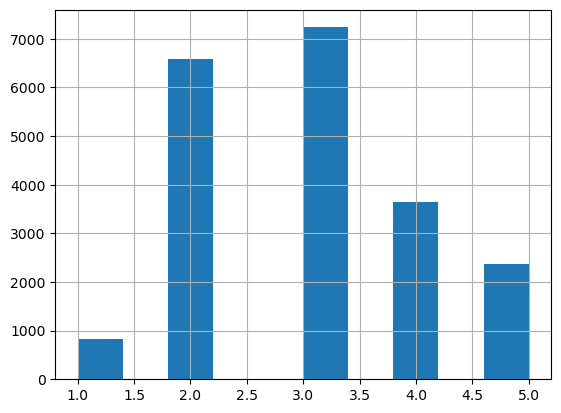

In [11]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0,1.5,3.0,4.5,6.0,np.inf],
                               labels=[1,2,3,4,5])
housing["income_cat"].hist()

In [12]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


Now I tried to  reshuffle the data on the basis of income category and take take 20% for testing and 80% for training

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=29) ## this line is used to split the data into training and testing data set using stratified sampling. n_splits is the number of re-shuffling & splitting iterations, test_size is the percentage of data that will be used for testing and random_state is used to ensure that the same random numbers are generated every time you run the code. This is important for reproducibility. ##
for train_index, test_index in split.split(housing,housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [14]:
strat_train_set['income_cat'].value_counts()/len(strat_train_set) 

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

now ww have to remove the income_cat so that dataset will back to original state

In [15]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis=1,inplace=True) ## this line is used to drop the income_cat column from the training and testing data set. This is done because we will not be using this column to train our machine learning model. ##

Discovering and visualizing training data set

<Axes: xlabel='longitude', ylabel='latitude'>

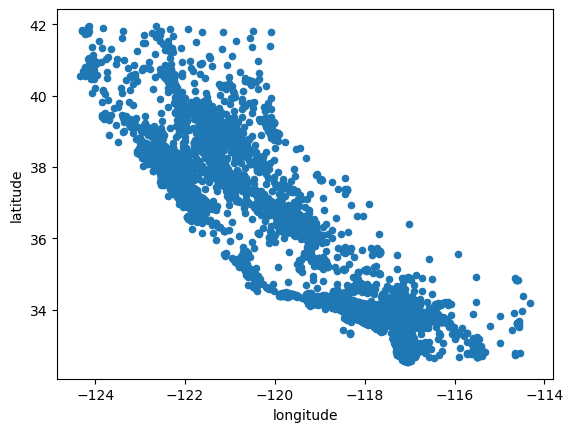

In [16]:
housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude")

alpha = 0.1 , make each individual point 90% transparent
SO NOW WE CAN EASILY SEE WHERE IS HIGH DENSITY POPULATION LIVES

<Axes: xlabel='longitude', ylabel='latitude'>

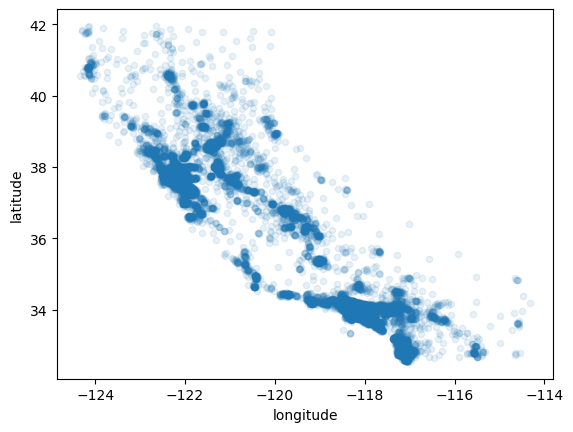

In [17]:
housing.plot(kind="scatter", x="longitude", y="latitude",alpha=0.1)

Now let's look at hosuing prices. 
The raidus of circle represents the district's poopulation (s) and the color represent the price (c).
We will use predefined color map (cmap) called jet, which range from blue (low value) to red (high prices)

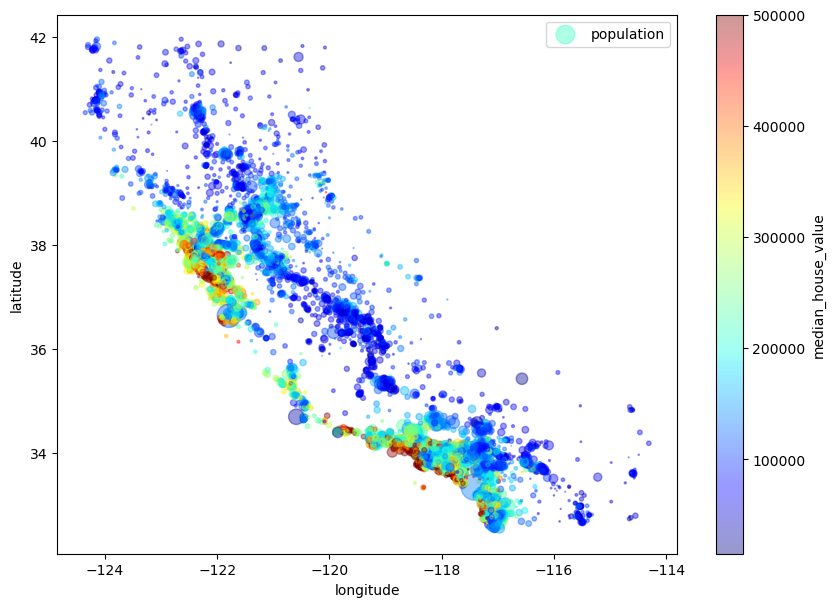

In [18]:
housing.plot(kind="scatter",
             x="longitude",
               y="latitude",
                 alpha=0.4,
                 s = housing["population"]/100,
                 label = "population",
                 figsize=(10,7),
                 c = "median_house_value",
                 cmap = plt.get_cmap("jet"),
                 colorbar = True,
)
plt.legend()

Compute standard correleation coefficient(also called Pearson's r) between every pair of attribute using the corr()

r = Σ[(X - X̄)(Y - Ȳ)] / sqrt(Σ(X - X̄)² * Σ(Y - Ȳ)²)


-1<=r<=1
when close to 1 it mean that strong correlation 

In [19]:
corr_matrix = housing.corr(numeric_only=True) ## this line is used to calculate the correlation matrix of the data frame. The correlation matrix is a table that shows the correlation coefficients between many variables. Each cell in the table shows the correlation between two variables. The value of the correlation coefficient ranges from -1 to 1. A value of 1 means that there is a perfect positive correlation between the two variables, a value of -1 means that there is a perfect negative correlation between the two variables and a value of 0 means that there is no correlation between the two variables. ##
# The 'numeric_only' argument prevents errors from text/categorical columns
corr_matrix["median_house_value"].sort_values(ascending=False)  

median_house_value    1.000000
median_income         0.691334
total_rooms           0.127498
housing_median_age    0.108481
households            0.060161
total_bedrooms        0.043991
population           -0.028239
longitude            -0.043977
latitude             -0.146227
Name: median_house_value, dtype: float64

another way to check for correlation between attribite is to use the pandas scatter_matrix() function

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

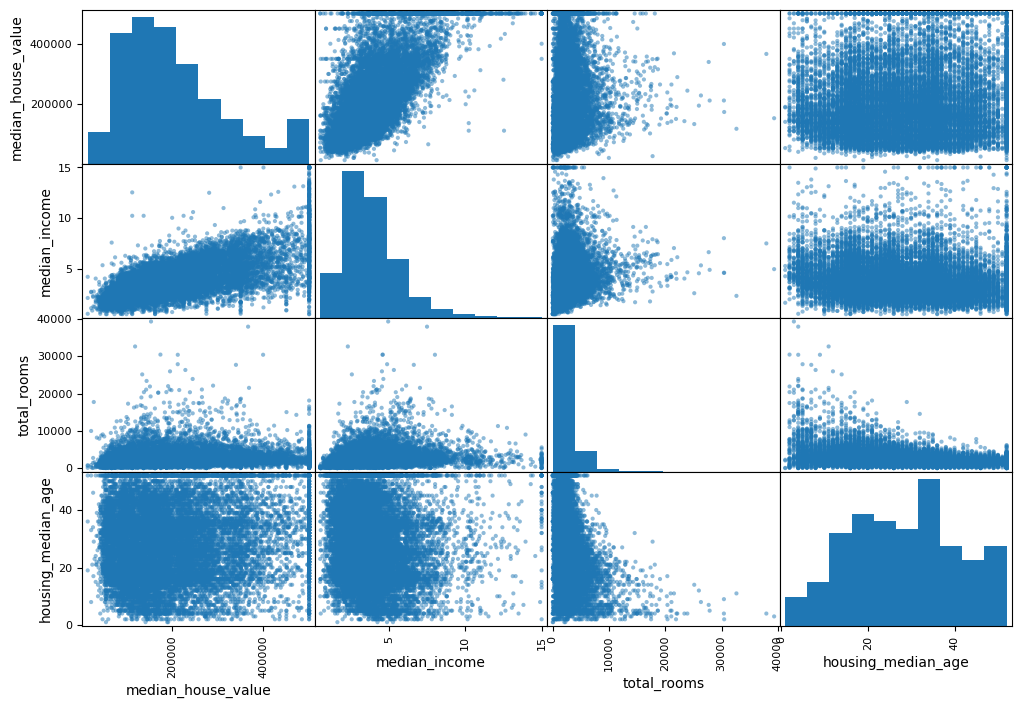

In [20]:
from pandas.plotting import scatter_matrix
attributes = ['median_house_value','median_income','total_rooms','housing_median_age']
scatter_matrix(housing[attributes], figsize=(12,8))

The most promising attribute to predict the median house value is the median
income, so let’s zoom in on their correlation scatterplot

<Axes: xlabel='median_income', ylabel='median_house_value'>

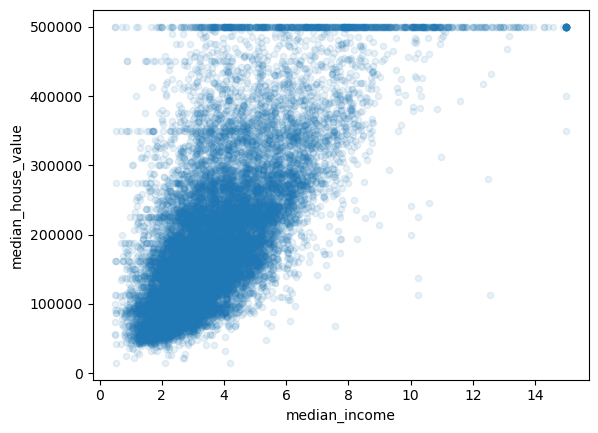

In [21]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",alpha=0.1)

Experimenting with attribute combinations


In [22]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households'] ## this line is used to create a new column called rooms_per_household which is the ratio of total_rooms to households. This is done because it is a good idea to create new features from the existing features in the data set. This can help to improve the performance of the machine learning model. ##
housing['bedrooms_per_room'] = housing['total_bedrooms']/housing['total_rooms'] ## this line is used to create a new column called bedrooms_per_room which is the ratio of total_bedrooms to total_rooms. This is done because it is a good idea to create new features from the existing features in the data set. This can help to improve the performance of the machine learning model. ##
housing['population_per_household'] = housing['population']/housing['households'] ## this line is used to create a new column called population_per_household which is the ratio of population to households. This is done because it is a good idea to create new features from the existing features in the data set. This can help to improve the performance of the machine learning model. ##
corr_matrix = housing.corr(numeric_only=True) ## this line is used to calculate the correlation matrix of the data frame. The correlation matrix is a table that shows the correlation coefficients between many variables. Each cell in the table shows the correlation between two variables. The value of the correlation coefficient ranges from -1 to 1. A value of 1 means that there is a perfect positive correlation between the two variables, a value of -1 means that there is a perfect negative correlation between the two variables and a value of 0 means that there is no correlation between the two variables. ##
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.691334
rooms_per_household         0.151990
total_rooms                 0.127498
housing_median_age          0.108481
households                  0.060161
total_bedrooms              0.043991
population_per_household   -0.021681
population                 -0.028239
longitude                  -0.043977
latitude                   -0.146227
bedrooms_per_room          -0.254016
Name: median_house_value, dtype: float64

Prepare the Data for MAchine Learning Algorithms

In [23]:
housing = strat_train_set.drop('median_house_value', axis=1) ## this line is used to create a new data frame called housing which is the training data set without the median_house_value column. This is done because we will be using the median_house_value column as the target variable for our machine learning model. ##
housing_labels = strat_train_set['median_house_value'].copy() ## this line is used to create a new data frame called housing_labels which is the median_house_value column from the training data set. This is done because we will be using this column as the target variable for our machine learning model. ##

Data Cleaning

most machine learning algo cannot work with missing features (total_bedrooms attribute) so let's create a few functions to tek care of them


In [24]:
housing.dropna(subset=["total_bedrooms"]) 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
8007,-118.11,33.85,36.0,887.0,163.0,482.0,157.0,4.1250,<1H OCEAN
18096,-122.04,37.33,26.0,2690.0,401.0,1264.0,429.0,7.7643,<1H OCEAN
5981,-117.74,34.10,29.0,2742.0,488.0,2477.0,532.0,3.5072,INLAND
3669,-118.39,34.23,43.0,1193.0,299.0,1184.0,320.0,2.1518,<1H OCEAN
14092,-117.11,32.76,21.0,2226.0,600.0,1085.0,533.0,2.2604,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
16800,-122.42,37.67,42.0,2274.0,429.0,1255.0,397.0,5.1205,NEAR OCEAN
2725,-115.55,32.79,22.0,565.0,162.0,692.0,141.0,1.2083,INLAND
20173,-119.17,34.29,18.0,3932.0,724.0,1896.0,680.0,5.2953,NEAR OCEAN
4644,-118.31,34.06,24.0,1336.0,453.0,1268.0,426.0,2.8202,<1H OCEAN


Handling Text and Categorical Attributes

So far we have only dealt with numerical attributes, but now let’s look at text
attributes. In this dataset, there is just one: the ocean_proximity attribute. Let’s look
at its value for the first 10 instances:


In [25]:
housing_cat = housing['ocean_proximity'] ## this line is used to create a new data frame called housing_cat which is the ocean_proximity column from the training data set. This is done because we will be using this column as a categorical variable for our machine learning model. ##
housing_cat.head(10)

8007      <1H OCEAN
18096     <1H OCEAN
5981         INLAND
3669      <1H OCEAN
14092    NEAR OCEAN
15992      NEAR BAY
10537     <1H OCEAN
6544      <1H OCEAN
948       <1H OCEAN
6193      <1H OCEAN
Name: ocean_proximity, dtype: object

It’s not arbitrary text: there are a limited number of possible values, each of which
represents a category. So this attribute is a categorical attribute. Most Machine Learn‐
ing algorithms prefer to work with numbers, so let’s convert these categories from
text to numbers. For this, we can use Scikit-Learn’s OrdinalEncoder class


In [29]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder() ## this line is used to create an instance of the OrdinalEncoder class from the sklearn.preprocessing module. The OrdinalEncoder class is used to encode categorical features as ordinal integers. This means that each category will be assigned a unique integer value based on the order of the categories. ##
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat.values.reshape(-1,1)) ## this line is used to fit the ordinal encoder to the housing_cat data and then transform the data into ordinal integers. The fit_transform method is used to fit the encoder to the data and then transform the data in one step. The reshape(-1,1) is used to reshape the data into a 2D array with one column and as many rows as needed. This is done because the fit_transform method expects a 2D array as input. ##
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [1.],
       [0.],
       [4.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

You can get the list of categories using the categories_ instance variable. It is a list
containing a 1D array of categories for each categorical attribute (in this case, a list
containing a single array since there is just one categorical attribute):


In [30]:
ordinal_encoder.categories_ ## this line is used to see the categories that were encoded by the ordinal encoder. The categories_ attribute of the ordinal encoder will show the unique categories that were found in the data and the order in which they were encoded. ##

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

One issue with this representation is that ML algorithms will assume that two nearby
values are more similar than two distant values. This may be fine in some cases (e.g.,
for ordered categories such as “bad,” “average,” “good,” and “excellent”), but it is obvi‐
ously not the case for the ocean_proximity column (for example, categories 0 and 4
are clearly more similar than categories 0 and 1). To fix this issue, a common solution is to create one binary attribute per category: one attribute equal to 1 when the cate‐
gory is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the cate‐
gory is “INLAND” (and 0 otherwise), and so on. This is called one-hot encoding,
because only one attribute will be equal to 1 (hot), while the others will be 0 (cold).
The new attributes are sometimes called dummy attributes. Scikit-Learn provides a
OneHotEncoder class to convert categorical values into one-hot vectors


In [48]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat_encoded)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [45]:
housing_cat_1hot.toarray() ## this line is used to convert the sparse matrix returned by the OneHotEncoder to a dense array. The OneHotEncoder returns a sparse matrix by default, which is a memory-efficient way to store the data. However, sometimes it is easier to work with a dense array, especially when we want to visualize the data or perform some operations on it. The toarray() method is used to convert the sparse matrix to a dense array. ##

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(16512, 5))

In [49]:
cat_encoder.categories_ ## this line is used to see the categories that were encoded by the one hot encoder. The categories_ attribute of the one hot encoder will show the unique categories that were found in the data and the order in which they were encoded. ##  

[array([0., 1., 2., 3., 4.])]

Custom Transformers